# Comprehensive Data Science Project: Sales Forecasting & Regional Performance

**Business problem:** The company wants to understand where its sales are strong
or weak across regions and products, get a short-term revenue forecast, and
have a simple way to estimate what a new deal might be worth before it's priced.

**Dataset:** `sales_data.csv` — 100 sales transactions from Jan to Apr 2024,
with columns `Date, Product, Quantity, Price, Customer_ID, Region, Total_Sales`.

**Approach:**
1. Load and clean the data
2. Exploratory Data Analysis (EDA)
3. Regional & product performance analysis
4. Revenue forecasting
5. Deal-value prediction model (feature engineering + model comparison)
6. Business insights & recommendations

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split

from src.data_processing import load_data, check_data_quality, add_features, get_weekly_revenue
from src.visualization import (
    plot_revenue_by_column, plot_weekly_trend, plot_correlation_heatmap,
    plot_region_product_heatmap, plot_actual_vs_predicted, plot_model_comparison,
)
from src.models import (
    prepare_features, compare_models, train_and_evaluate,
    forecast_next_weeks, save_model, predict_deal_value,
)

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 1. Load and Clean the Data

In [2]:
df = load_data()
df.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [3]:
check_data_quality(df)

Rows, columns: (100, 7)

Missing values per column:
Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64

Duplicate rows: 0
Rows where Quantity * Price != Total_Sales: 0


Good news: no missing values, no duplicate rows, and `Quantity * Price` matches `Total_Sales` for every row. The data doesn't need cleaning.

In [4]:
df = add_features(df)
df.describe()

,Date,Quantity,Price,Total_Sales,Week
count,100,100.00,100.00,100.00,100.00
mean,2024-02-19 12:00:00,4.78,"25,808.51","123,650.48",7.65
min,2024-01-01 00:00:00,1.00,"1,308.00","6,540.00",1.00
25%,2024-01-25 18:00:00,2.75,"14,965.25","39,517.50",4.00
50%,2024-02-19 12:00:00,5.00,"24,192.00","97,955.50",8.00
75%,2024-03-15 06:00:00,7.00,"38,682.25","175,792.50",11.00
max,2024-04-09 00:00:00,9.00,"49,930.00","373,932.00",15.00
std,NaN,2.59,"13,917.63","100,161.09",4.15


## 2. Exploratory Data Analysis

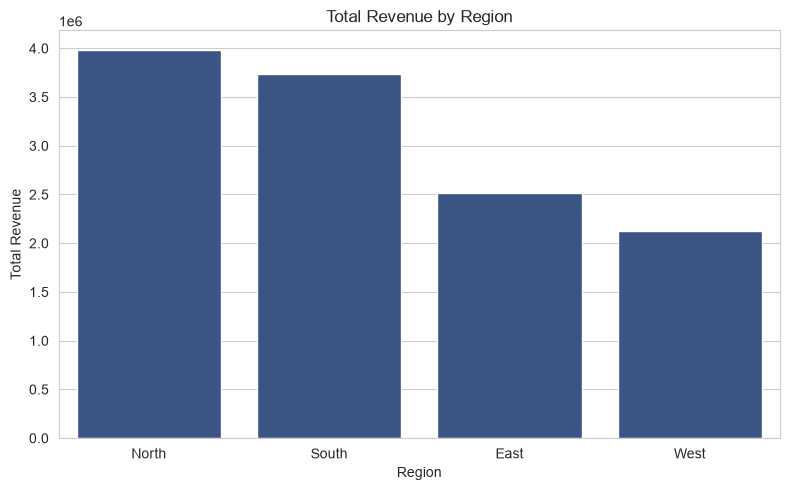

In [5]:
plot_revenue_by_column(df, "Region", "Total Revenue by Region")
plt.show()

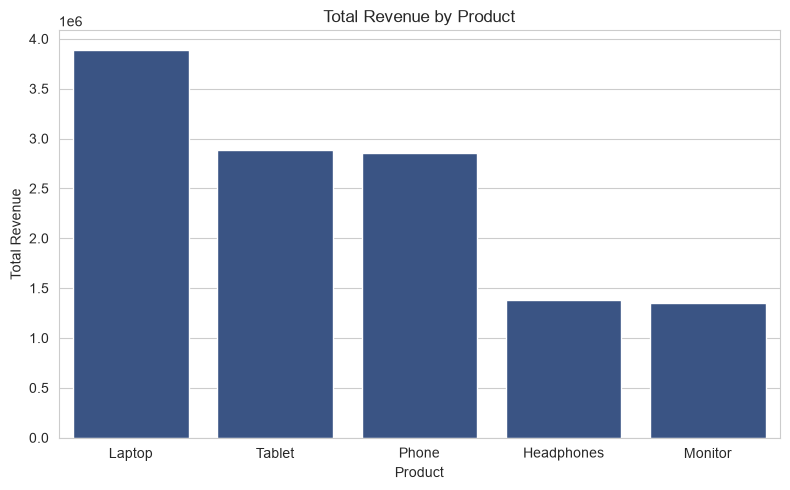

In [6]:
plot_revenue_by_column(df, "Product", "Total Revenue by Product")
plt.show()

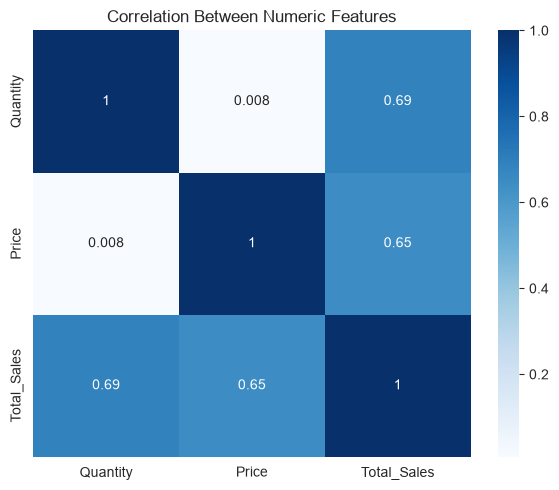

In [7]:
plot_correlation_heatmap(df)
plt.show()

Quantity and Price are both positively correlated with Total_Sales, which makes sense since `Total_Sales = Quantity * Price`. Quantity and Price themselves are not correlated with each other.

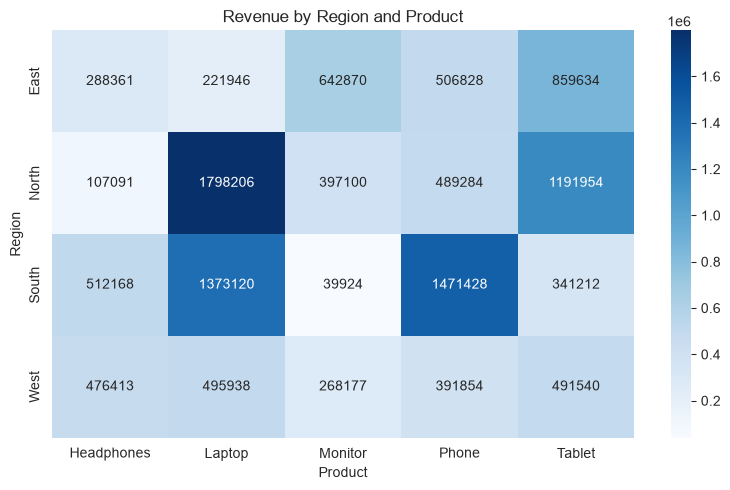

In [8]:
plot_region_product_heatmap(df)
plt.show()

**Observation:** North and South bring in the most revenue, while West is noticeably behind — worth investigating below.

## 3. Is the Regional Difference Significant?

A one-way ANOVA test checks whether average deal size really differs across regions, or if what we're seeing could just be random variation in a small sample.

In [9]:
region_groups = [group["Total_Sales"].values for name, group in df.groupby("Region")]
f_stat, p_value = stats.f_oneway(*region_groups)
print(f"F-statistic: {f_stat:.2f}")
print(f"p-value: {p_value:.3f}")

if p_value < 0.05:
    print("Result: statistically significant difference between regions (p < 0.05)")
else:
    print("Result: no statistically significant difference between regions")

F-statistic: 2.16
p-value: 0.097
Result: no statistically significant difference between regions


In [10]:
df.groupby("Region")["Total_Sales"].agg(["mean", "count"]).sort_values("mean", ascending=False)

,mean,count
Region,,
North,"142,272.68",28
South,"138,438.96",27
East,"132,612.58",19
West,"81,689.31",26


The ANOVA test does not quite reach statistical significance at the 5% level (p ≈ 0.10), though it's close and the pattern is suggestive. With only 100 transactions spread across 4 regions, the sample may simply be too small to prove the gap statistically — but West's average deal size is still clearly the lowest in the descriptive numbers above, and the drop comes from fewer units per deal rather than a different product mix (product revenue share looks similar across regions in the heatmap). This is worth watching as more data comes in, and worth a business-side look regardless of the statistical test.

## 4. Revenue Forecasting

A simple weekly trend is used here since we only have ~14 weeks of data. Two approaches are compared on the last 3 weeks before choosing one for the real forecast: a flat average, and a linear trend line.

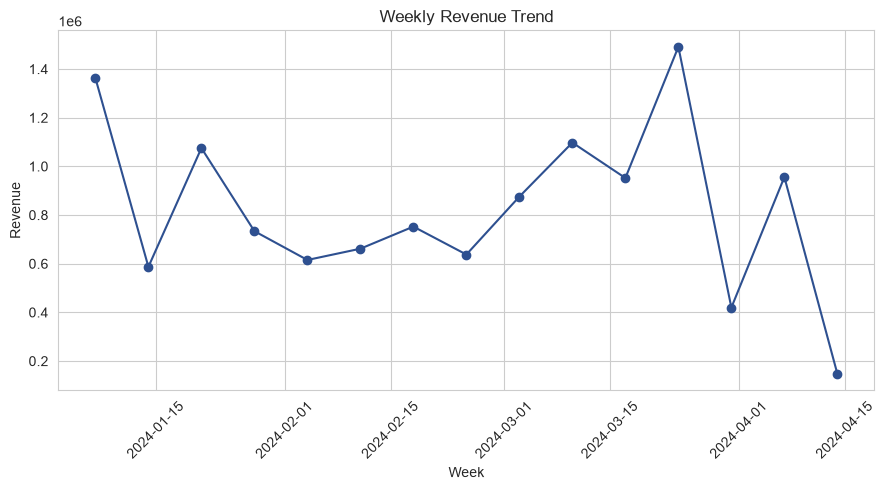

In [11]:
weekly_revenue = get_weekly_revenue(df)
plot_weekly_trend(weekly_revenue)
plt.show()

In [12]:
forecast, comparison = forecast_next_weeks(weekly_revenue, n_weeks=4)
print("MAE on the last 3 weeks (lower is better):")
print(comparison)
forecast

MAE on the last 3 weeks (lower is better):
{'Average MAE': 430714.0, 'Trend MAE': 545907.5780885782}


2024-04-21   824,336.53
2024-04-28   824,336.53
2024-05-05   824,336.53
2024-05-12   824,336.53
Freq: W-SUN, Name: Forecast, dtype: float64

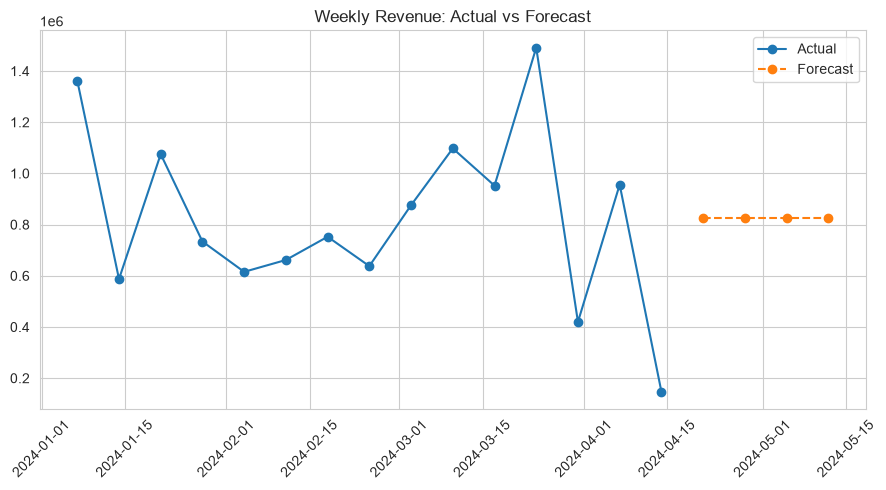

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(weekly_revenue.index, weekly_revenue.values, marker="o", label="Actual")
ax.plot(forecast.index, forecast.values, marker="o", linestyle="--", label="Forecast")
ax.set_title("Weekly Revenue: Actual vs Forecast")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The flat average had a lower error on the held-out weeks than the trend line, so the forecast simply carries forward the historical average revenue (~₹870K/week) rather than assuming a trend that the data doesn't clearly support.

## 5. Deal-Value Prediction Model

Can we estimate what a deal is worth just from its Product, Region and Quantity — useful for sizing a pipeline before a deal is priced? Note that `Price` is deliberately left out of the features, since `Total_Sales = Quantity * Price` exactly, and including Price would let the model just multiply it back out instead of learning anything.

In [14]:
X, y, encoder = prepare_features(df)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training rows:", len(X_train), " Test rows:", len(X_test))

Training rows: 80  Test rows: 20


### Comparing models with 5-fold cross-validation

In [15]:
cv_results = compare_models(X_train, y_train)
cv_results

,Model,R2
0,Ridge Regression,0.23
1,Linear Regression,0.22
2,Random Forest,0.19


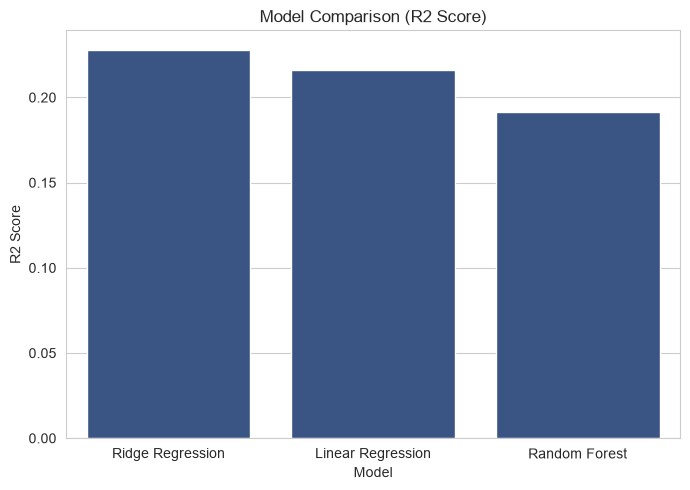

In [16]:
plot_model_comparison(cv_results)
plt.show()

Ridge Regression performs best on cross-validation, closely followed by plain Linear Regression. It's chosen as the final model — Ridge's regularization also helps a bit since we have relatively few training rows.

In [17]:
from sklearn.linear_model import Ridge

final_model = Ridge(alpha=1.0)
final_model, metrics, y_pred = train_and_evaluate(final_model, X_train, X_test, y_train, y_test)
metrics

{'MAE': 60563.213046413475,
 'RMSE': np.float64(76214.76641442838),
 'R2': 0.4558063546611638}

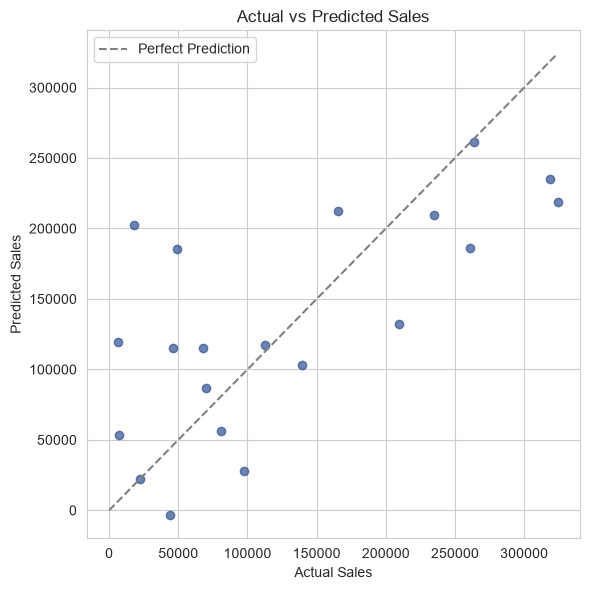

In [18]:
plot_actual_vs_predicted(y_test, y_pred)
plt.show()

### What drives deal value?

In [19]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": final_model.coef_
}).sort_values("Coefficient", ascending=False)
coef_df

,Feature,Coefficient
9,Quantity,"25,983.58"
1,Product_Laptop,"16,756.88"
6,Region_North,"10,019.51"
0,Product_Headphones,"9,884.72"
3,Product_Phone,"7,576.69"
7,Region_South,"3,069.07"
5,Region_East,"-3,842.29"
8,Region_West,"-9,246.28"
2,Product_Monitor,"-13,508.53"
4,Product_Tablet,"-20,709.76"


Quantity has the largest positive effect on deal value, as expected. Among products, Laptops and Phones add the most value; among regions, North and East add a positive effect while West and Tablets/Monitors pull the value down — consistent with what we saw in the EDA.

In [20]:
save_model(final_model, encoder)
example = predict_deal_value("Laptop", "North", 5, final_model, encoder)
print(f"Example prediction — Laptop, North, 5 units: ₹{example:,.0f}")

Example prediction — Laptop, North, 5 units: ₹157,224


## 6. Business Insights & Recommendations

1. **West region needs attention.** Its average deal size is clearly the lowest of the four regions (an ANOVA test gives p ≈ 0.10, just short of the usual 5% cutoff, likely because the sample is small). The gap comes from fewer units per deal, not a different product mix. Sales strategy in West should
   focus on increasing deal size (e.g. bundling, upselling), not the product catalog.
2. **Revenue forecast:** with only 14 weeks of history, there's no strong
   trend yet — the best estimate for the next few weeks is close to the
   historical average of ~₹870K/week. This should be revisited as more data
   comes in.
3. **Deal-value model:** the Ridge Regression model can estimate a deal's
   value from Product, Region and Quantity with reasonable accuracy
   (R² ≈ 0.46 on the test set), useful for early pipeline planning — though
   it explains less than half the variation, so it should be used as a rough
   guide, not a final price.
4. **Laptops and Phones are the most valuable product lines** and, combined
   with North and South regions, make up the bulk of revenue — worth
   prioritizing in sales efforts.

## Limitations

- Only 100 transactions and ~14 weeks of data — all results should be
  re-checked once more data is collected.
- The forecast is a simple average/trend comparison, not a full time-series
  model (e.g. ARIMA), which would need more historical data to be reliable.
- The deal-value model only uses 3 input features; adding more (e.g. customer
  history, season) could improve accuracy.